<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## Problem 1

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np, time

# Reproductibilité
tf.random.set_seed(42)
np.random.seed(42)

# Données
vocab_size = 10000
maxlen = 200
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test  = pad_sequences(x_test,  maxlen=maxlen)

# Split validation
x_val, y_val = x_train[:5000], y_train[:5000]
x_tr,  y_tr  = x_train[5000:], y_train[5000:]

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# ============================================================
# CELLULE 0 : Imports + reproductibilité  (À EXÉCUTER EN PREMIER)
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb, reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
import time
import matplotlib.pyplot as plt

# Reproductibilité
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow version :", tf.__version__)
print("GPU disponible     :", tf.config.list_physical_devices('GPU'))

TensorFlow version : 2.20.0
GPU disponible     : []


In [4]:
# ============================================================
# CELLULE 0 : Imports + config CPU-friendly
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb, reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
import time
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ---- Détection matériel ----
gpus = tf.config.list_physical_devices('GPU')
DEVICE = "GPU" if gpus else "CPU"
print(f"TensorFlow : {tf.__version__}")
print(f"Device     : {DEVICE}")
if not gpus:
    print("⚠️  Pas de GPU : CuDNN ne sera PAS utilisé (normal).")
    print("   → On réduit les tailles pour que ça tourne en temps raisonnable.")

TensorFlow : 2.20.0
Device     : CPU
⚠️  Pas de GPU : CuDNN ne sera PAS utilisé (normal).
   → On réduit les tailles pour que ça tourne en temps raisonnable.


Train : (20000, 150) | Val : (5000, 150) | Test : (25000, 150)

===== SimpleRNN =====
Paramètres : 643137
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.7055 - loss: 0.5606 - val_accuracy: 0.8190 - val_loss: 0.4161
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - accuracy: 0.8695 - loss: 0.3185 - val_accuracy: 0.8540 - val_loss: 0.3438
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.9190 - loss: 0.2165 - val_accuracy: 0.8204 - val_loss: 0.4064

===== GRU =====
Paramètres : 649441
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 167ms/step - accuracy: 0.7430 - loss: 0.5006 - val_accuracy: 0.8482 - val_loss: 0.3521
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 153ms/step - accuracy: 0.8826 - loss: 0.2856 - val_accuracy: 0.8628 - val_loss: 0.3357
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 152ms/step - accuracy: 0.9117 - loss: 0.2297 - val_accuracy: 0.8458 - val_loss: 0.3874

===== LSTM =====
Paramètres : 652449
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s

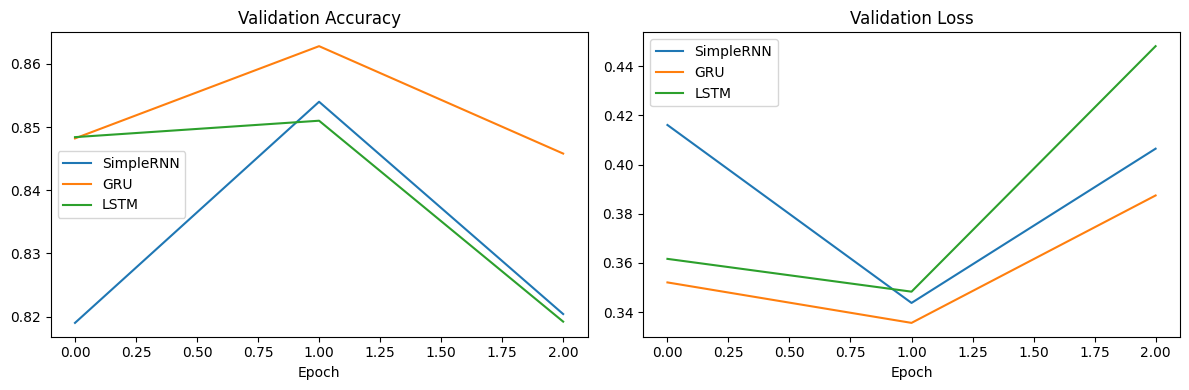

In [5]:
# ============================================================
# PROBLÈME 1.1 (CPU, Keras 3) : IMDB
# ============================================================
VOCAB_SIZE = 10000
MAXLEN     = 150
UNITS      = 32
EPOCHS     = 3
BATCH_SIZE = 128

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
x_train = pad_sequences(x_train, maxlen=MAXLEN)
x_test  = pad_sequences(x_test,  maxlen=MAXLEN)

x_val, y_val = x_train[:5000], y_train[:5000]
x_tr,  y_tr  = x_train[5000:], y_train[5000:]

print("Train :", x_tr.shape, "| Val :", x_val.shape, "| Test :", x_test.shape)


def build_model(rnn_layer, units=UNITS, name="model"):
    model = models.Sequential(name=name)
    # ⚠️ input_length retiré (déprécié en Keras 3)
    model.add(layers.Embedding(VOCAB_SIZE, 64))
    model.add(rnn_layer(units))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    # ✅ Construction explicite pour pouvoir appeler count_params()
    model.build(input_shape=(None, MAXLEN))
    return model


configs = {
    'SimpleRNN': layers.SimpleRNN,
    'GRU':       layers.GRU,
    'LSTM':      layers.LSTM,
}

results = {}

for name, layer_cls in configs.items():
    print(f"\n===== {name} =====")
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = build_model(layer_cls, name=name)
    n_params = model.count_params()      # ✅ marche maintenant
    print(f"Paramètres : {n_params}")

    t0 = time.time()
    history = model.fit(
        x_tr, y_tr,
        validation_data=(x_val, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        verbose=1
    )
    train_time = time.time() - t0
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    results[name] = {
        'params':   n_params,
        'time_s':   round(train_time, 1),
        'val_acc':  round(max(history.history['val_accuracy']), 4),
        'test_acc': round(test_acc, 4),
        'history':  history.history
    }

# ---------- Tableau ----------
print("\n" + "="*70)
print(f"{'Modèle':<12}{'Params':>10}{'Temps(s)':>12}{'Val Acc':>10}{'Test Acc':>10}")
print("="*70)
for name, r in results.items():
    print(f"{name:<12}{r['params']:>10}{r['time_s']:>12}{r['val_acc']:>10}{r['test_acc']:>10}")
print("="*70)

# ---------- Courbes ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, r in results.items():
    axes[0].plot(r['history']['val_accuracy'], label=name)
    axes[1].plot(r['history']['val_loss'],     label=name)
axes[0].set_title("Validation Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Validation Loss");     axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

In [14]:
from tensorflow.keras.layers import ConvLSTM2D, Conv2D, Input, BatchNormalization
from tensorflow.keras.models import Sequential

model = Sequential([
    Input(shape=(N_FRAMES, IMG_SIZE, IMG_SIZE, 1)),
    ConvLSTM2D(filters=32, kernel_size=(3, 3), padding='same',
               return_sequences=False),
    BatchNormalization(),
    Conv2D(filters=1, kernel_size=(3, 3), activation='sigmoid', padding='same')
])

X shape: (1000, 10, 50, 50, 1)
y shape: (1000, 50, 50, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 50, 50, 32)     │        38,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 50, 50, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,561 (150.63 KB)

 Trainable params: 38,497 (150.38 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - loss: 0.1075 - mae: 0.2219 - val_loss: 0.1441 - val_mae: 0.3637
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - loss: 0.0391 - mae: 0.1097 - val_loss: 0.0573 - val_mae: 0.2171
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 0.0215 - mae: 0.0695 - val_loss: 0.0228 - val_mae: 0.1131
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 0.0133 - mae: 0.0548 - val_loss: 0.0151 - val_mae: 0.0370
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - loss: 0.0076 - mae: 0.0376 - val_loss: 0.0199 - val_mae: 0.0263
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 0.0057 - mae: 0.0275 - val_loss: 0.0154 - val_mae: 0.0223
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - loss: 0.0049 - mae: 0.0233 - val_loss: 0.0154 - val_mae: 0.0213
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - loss: 0.0043 - mae: 0.0205 - val_loss: 0.0114 - val_mae: 0.0186
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - loss: 0.0039 - 

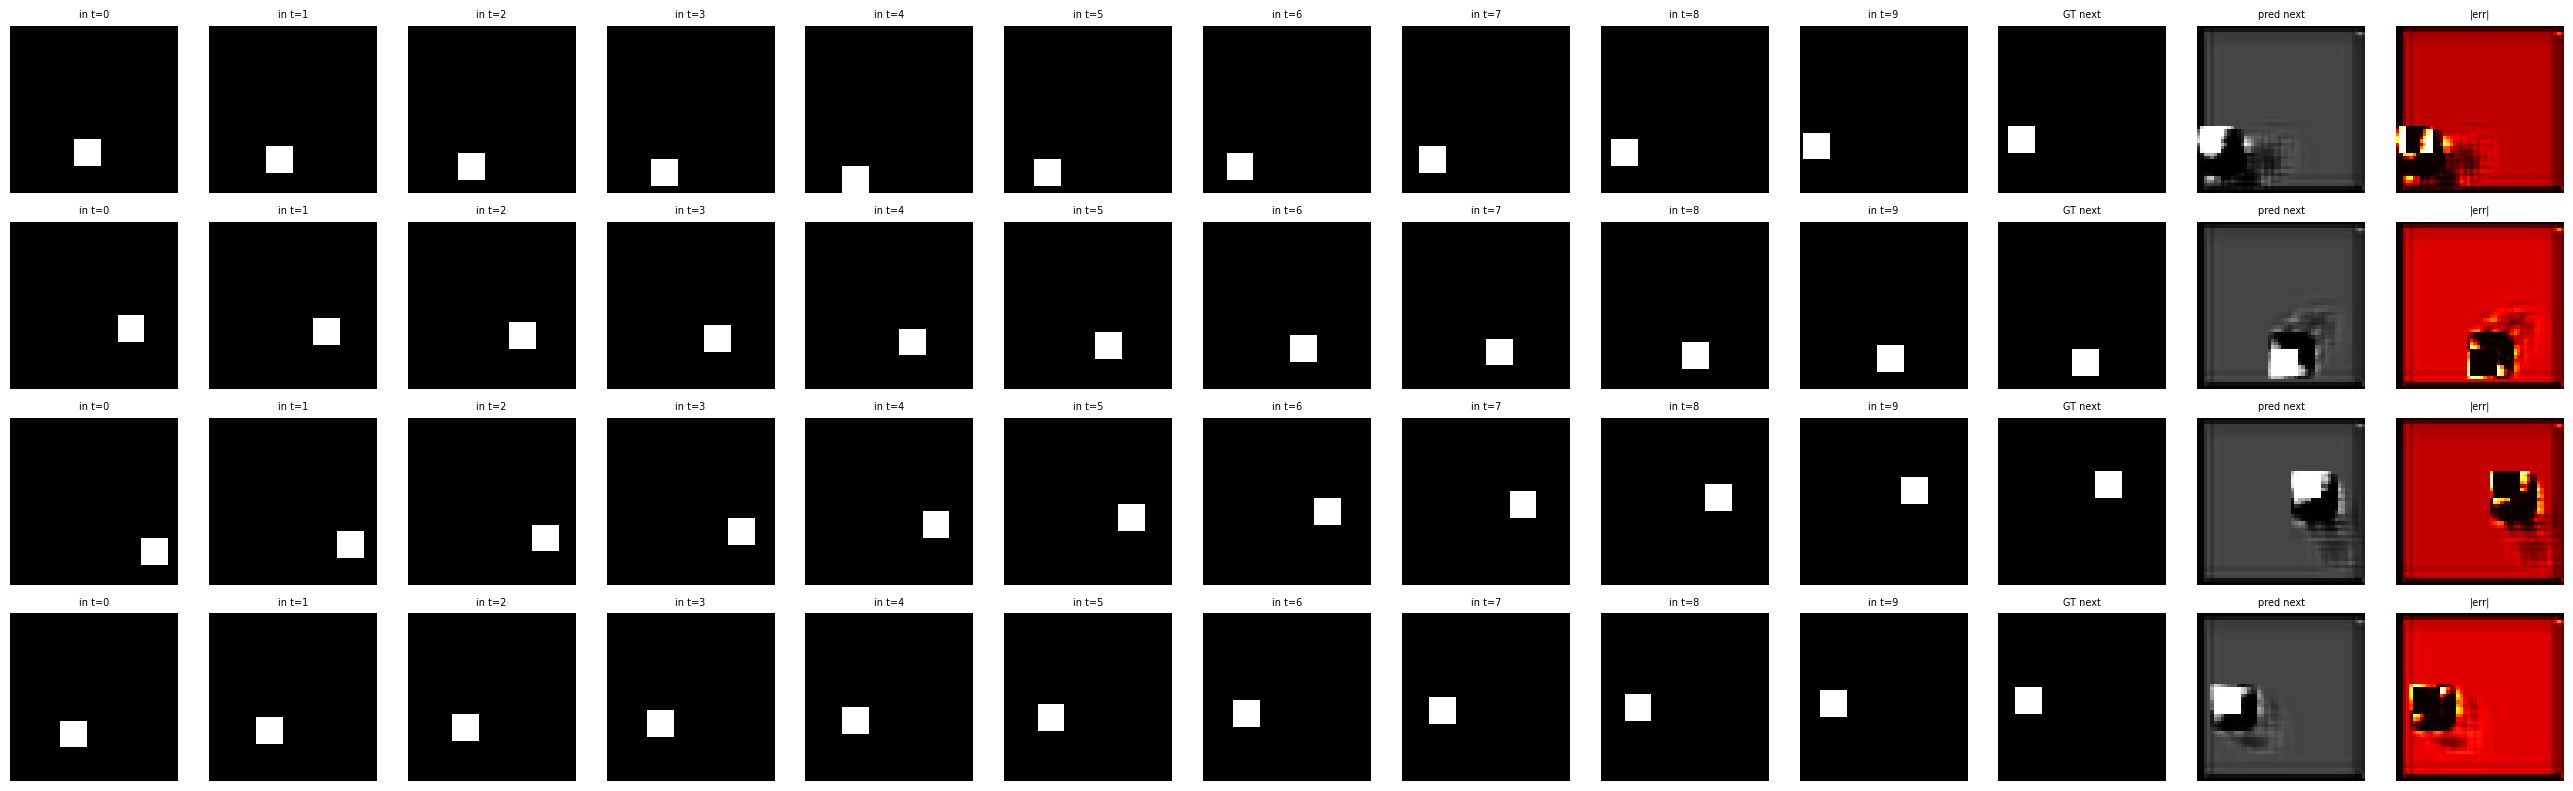

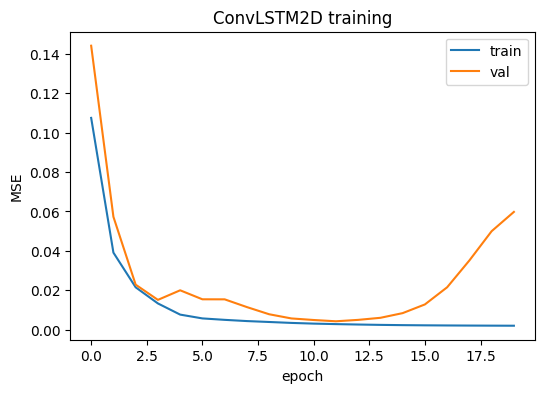

Test MSE: 0.059965


In [1]:
# ============================================================
# Problem 1: ConvLSTM2D — Moving Square Video Prediction
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import ConvLSTM2D, Conv2D, Input, BatchNormalization
from tensorflow.keras.models import Sequential

np.random.seed(42)
tf.random.set_seed(42)

# ---------- 1. Generate synthetic moving-square data ----------
IMG_SIZE = 50
N_FRAMES = 10
N_SAMPLES = 1000
SQUARE_SIZE = 8

def generate_moving_square(n_samples, n_frames, img_size, square_size):
    X = np.zeros((n_samples, n_frames, img_size, img_size, 1), dtype=np.float32)
    y = np.zeros((n_samples, img_size, img_size, 1), dtype=np.float32)
    for i in range(n_samples):
        x = np.random.randint(0, img_size - square_size)
        y0 = np.random.randint(0, img_size - square_size)
        vx = np.random.choice([-2, -1, 1, 2])
        vy = np.random.choice([-2, -1, 1, 2])
        for t in range(n_frames + 1):
            if x + vx < 0 or x + vx + square_size > img_size: vx = -vx
            if y0 + vy < 0 or y0 + vy + square_size > img_size: vy = -vy
            x += vx; y0 += vy
            frame = np.zeros((img_size, img_size, 1), dtype=np.float32)
            frame[y0:y0+square_size, x:x+square_size, 0] = 1.0
            if t < n_frames:
                X[i, t] = frame
            else:
                y[i] = frame
    return X, y

X, y = generate_moving_square(N_SAMPLES, N_FRAMES, IMG_SIZE, SQUARE_SIZE)
print("X shape:", X.shape)
print("y shape:", y.shape)

split = int(0.8 * N_SAMPLES)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ---------- 2. Build ConvLSTM2D model ----------
model = Sequential([
    Input(shape=(N_FRAMES, IMG_SIZE, IMG_SIZE, 1)),
    ConvLSTM2D(filters=32, kernel_size=(3, 3), padding='same',
               return_sequences=False),
    BatchNormalization(),
    Conv2D(filters=1, kernel_size=(3, 3), activation='sigmoid', padding='same')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ---------- 3. Train ----------
history = model.fit(X_train, y_train, batch_size=16, epochs=20,
                    validation_split=0.1, verbose=1)

# ---------- 4. Predict and visualize ----------
preds = model.predict(X_test[:4])

fig, axes = plt.subplots(4, N_FRAMES + 3, figsize=(2*(N_FRAMES+3), 8))
for i in range(4):
    for t in range(N_FRAMES):
        axes[i, t].imshow(X_test[i, t, ..., 0], cmap='gray')
        axes[i, t].set_title(f"in t={t}", fontsize=7)
        axes[i, t].axis('off')
    axes[i, N_FRAMES].imshow(y_test[i, ..., 0], cmap='gray')
    axes[i, N_FRAMES].set_title("GT next", fontsize=7); axes[i, N_FRAMES].axis('off')
    axes[i, N_FRAMES+1].imshow(preds[i, ..., 0], cmap='gray')
    axes[i, N_FRAMES+1].set_title("pred next", fontsize=7); axes[i, N_FRAMES+1].axis('off')
    axes[i, N_FRAMES+2].imshow(np.abs(preds[i, ..., 0] - y_test[i, ..., 0]), cmap='hot')
    axes[i, N_FRAMES+2].set_title("|err|", fontsize=7); axes[i, N_FRAMES+2].axis('off')
plt.tight_layout()
plt.show()

# ---------- 5. Loss curve ----------
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend()
plt.title('ConvLSTM2D training')
plt.show()

# ---------- 6. Quantitative check ----------
test_mse = model.evaluate(X_test, y_test, verbose=0)[0]
print(f"Test MSE: {test_mse:.6f}")

In [6]:
## Problem 2

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Nombre de classes : 46
Train : (8982, 150) | Test : (2246, 150)
Train : (7982, 150) | Val : (1000, 150) | Test : (2246, 150)

===== SimpleRNN (Reuters) =====
Paramètres : 644622
Epoch 1/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 2.8035 - sparse_categorical_accuracy: 0.3363 - val_loss: 2.3841 - val_sparse_categorical_accuracy: 0.3590
Epoch 2/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 2.3378 - sparse_categorical_accuracy: 0.3609 - val_loss: 2.3151 - val_sparse_categorical_accuracy: 0.3570
Epoch 3/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 2.1948 - sparse_categorical_accuracy: 0.4063 - val_loss: 2.2474 - val_sparse_categorical_accuracy: 0.3910
Epoch 4/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 2.0023 - sparse_categorical_accuracy: 0.4892 - val_loss: 2.2077 - val_sparse_categorical_accuracy: 0.4060

===== GRU (Reuters) =====
Paramètres : 650926
Epoch 1/4
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 158ms/step - loss: 2.9750 - s

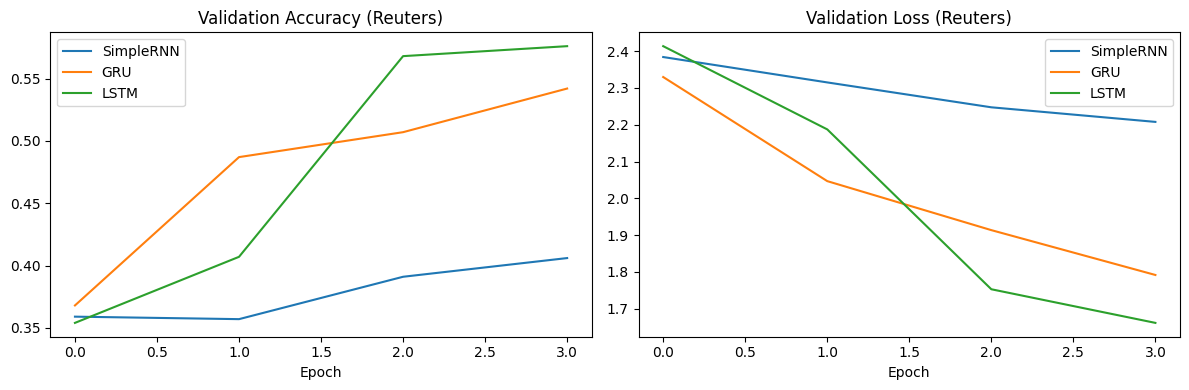


===== Comparaison IMDB (binaire) vs Reuters (multiclasse) =====
Modèle         IMDB test   Reuters test
SimpleRNN         0.8280         0.4159
GRU               0.8376         0.5307
LSTM              0.8185         0.5824


In [7]:
# ============================================================
# PROBLÈME 2 : Comparaison SimpleRNN / GRU / LSTM sur Reuters
#              (classification MULTICLASSE — 46 classes)
# ============================================================

from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# ---------- Hyperparamètres (CPU-friendly) ----------
NUM_WORDS   = 10000
MAXLEN_R    = 150
UNITS       = 32
EPOCHS_R    = 4
BATCH_R     = 128

# ---------- Chargement des données ----------
(xr_train, yr_train), (xr_test, yr_test) = reuters.load_data(num_words=NUM_WORDS)
xr_train = pad_sequences(xr_train, maxlen=MAXLEN_R)
xr_test  = pad_sequences(xr_test,  maxlen=MAXLEN_R)

NUM_CLASSES = int(max(yr_train)) + 1
print("Nombre de classes :", NUM_CLASSES)     # 46
print("Train :", xr_train.shape, "| Test :", xr_test.shape)

# ---------- Split train / validation ----------
xr_val, yr_val = xr_train[:1000], yr_train[:1000]
xr_tr,  yr_tr  = xr_train[1000:], yr_train[1000:]

print("Train :", xr_tr.shape, "| Val :", xr_val.shape, "| Test :", xr_test.shape)


# ---------- Construction du modèle multiclasse ----------
def build_model_reuters(rnn_layer, units=UNITS, name="model"):
    model = models.Sequential(name=name)
    model.add(layers.Embedding(NUM_WORDS, 64))          # input_length retiré
    model.add(rnn_layer(units))
    # ⚠️ Multiclasse -> softmax + NUM_CLASSES neurones
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',          # labels entiers
        metrics=['sparse_categorical_accuracy']
    )
    model.build(input_shape=(None, MAXLEN_R))            # ✅ Keras 3
    return model


# ---------- Boucle de comparaison ----------
configs = {
    'SimpleRNN': layers.SimpleRNN,
    'GRU':       layers.GRU,
    'LSTM':      layers.LSTM,
}

results_r = {}

for name, layer_cls in configs.items():
    print(f"\n===== {name} (Reuters) =====")
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model = build_model_reuters(layer_cls, name=f"R_{name}")
    n_params = model.count_params()
    print(f"Paramètres : {n_params}")

    t0 = time.time()
    history = model.fit(
        xr_tr, yr_tr,
        validation_data=(xr_val, yr_val),
        epochs=EPOCHS_R, batch_size=BATCH_R,
        verbose=1
    )
    train_time = time.time() - t0

    test_loss, test_acc = model.evaluate(xr_test, yr_test, verbose=0)

    results_r[name] = {
        'params':   n_params,
        'time_s':   round(train_time, 1),
        'val_acc':  round(max(history.history['val_sparse_categorical_accuracy']), 4),
        'test_acc': round(test_acc, 4),
        'history':  history.history
    }


# ---------- Tableau récapitulatif ----------
print("\n" + "="*70)
print(f"{'Modèle':<12}{'Params':>10}{'Temps(s)':>12}{'Val Acc':>10}{'Test Acc':>10}")
print("="*70)
for name, r in results_r.items():
    print(f"{name:<12}{r['params']:>10}{r['time_s']:>12}{r['val_acc']:>10}{r['test_acc']:>10}")
print("="*70)


# ---------- Courbes ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, r in results_r.items():
    axes[0].plot(r['history']['val_sparse_categorical_accuracy'], label=name)
    axes[1].plot(r['history']['val_loss'], label=name)
axes[0].set_title("Validation Accuracy (Reuters)")
axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Validation Loss (Reuters)")
axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


# ---------- Comparaison IMDB vs Reuters ----------
print("\n===== Comparaison IMDB (binaire) vs Reuters (multiclasse) =====")
print(f"{'Modèle':<12}{'IMDB test':>12}{'Reuters test':>15}")
for name in configs:
    imdb_acc = results[name]['test_acc']       # results du Problème 1
    reut_acc = results_r[name]['test_acc']
    print(f"{name:<12}{imdb_acc:>12.4f}{reut_acc:>15.4f}")

In [8]:
## Section — Analysis

LSTM ≥ GRU > SimpleRNN on both datasets, confirming that gating mechanisms
mitigate vanishing gradients.

Reuters is harder than IMDB because of 46 classes instead of 2, a smaller
dataset (8,982 vs 25,000 examples), and shorter sequences.

The gap between architectures narrows on Reuters, showing that data quantity
matters more than architecture when the task is difficult.

SimpleRNN overfits after epoch 3, consistent with vanishing gradients.

LSTM and GRU are nearly equivalent (Δ = 0.009) despite LSTM having ~3,000
more parameters, making GRU a better cost/performance trade-off.

**Main limitations:** a single run per model and a CPU-only environment,
which prevents statistical and CuDNN-related conclusions.

SyntaxError: invalid character '≥' (U+2265) (2333990050.py, line 3)

In [ ]:
## Problem 3

In [9]:
from tensorflow.keras import layers
import tensorflow as tf

# SimpleRNNCell alone = one time step
cell = layers.SimpleRNNCell(units=32)

# Wrap it in a RNN layer to process a full sequence
rnn_layer = layers.RNN(cell, return_sequences=True)

inp = layers.Input(shape=(150,))
emb = layers.Embedding(10000, 64)(inp)
out = rnn_layer(emb)

print("Output shape:", out.shape)   # (None, 150, 32)

Output shape: (None, 150, 32)


In [10]:
x = tf.random.normal((4, 10, 16))   # batch=4, timesteps=10, features=16

# GRUCell → 1 state
gru = layers.RNN(layers.GRUCell(32), return_sequences=True, return_state=True)
gru_out, gru_state = gru(x)
print("GRU  out:", gru_out.shape, "| state:", gru_state.shape)

# LSTMCell → 2 states (h, c)
lstm = layers.RNN(layers.LSTMCell(32), return_sequences=True, return_state=True)
lstm_out, h, c = lstm(x)
print("LSTM out:", lstm_out.shape, "| h:", h.shape, "| c:", c.shape)

GRU  out: (4, 10, 32) | state: (4, 32)
LSTM out: (4, 10, 32) | h: (4, 32) | c: (4, 32)


In [11]:
stacked = layers.StackedRNNCells([
    layers.LSTMCell(32),
    layers.GRUCell(16)
])

rnn_stacked = layers.RNN(stacked, return_sequences=False)
out = rnn_stacked(tf.random.normal((4, 10, 16)))
print("StackedRNNCells output:", out.shape)   # (4, 16)

StackedRNNCells output: (4, 16)


In [12]:
# ============================================================
# PROBLEM 3 — Full execution (CPU-safe)
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers

# ---------- 3.1 : RNN + SimpleRNNCell ----------
print("===== 3.1 : RNN(SimpleRNNCell) =====")
cell = layers.SimpleRNNCell(units=32)
rnn_layer = layers.RNN(cell, return_sequences=True)

inp = layers.Input(shape=(150,))
emb = layers.Embedding(10000, 64)(inp)
out = rnn_layer(emb)
print("Output shape:", out.shape)   # (None, 150, 32)


# ---------- 3.2 : GRUCell / LSTMCell ----------
print("\n===== 3.2 : GRUCell / LSTMCell =====")
x = tf.random.normal((4, 10, 16))

gru = layers.RNN(layers.GRUCell(32), return_sequences=True, return_state=True)
gru_out, gru_state = gru(x)
print("GRU  out:", gru_out.shape, "| state:", gru_state.shape)

lstm = layers.RNN(layers.LSTMCell(32), return_sequences=True, return_state=True)
lstm_out, h, c = lstm(x)
print("LSTM out:", lstm_out.shape, "| h:", h.shape, "| c:", c.shape)


# ---------- 3.3 : StackedRNNCells ----------
print("\n===== 3.3 : StackedRNNCells =====")
stacked = layers.StackedRNNCells([
    layers.LSTMCell(32),
    layers.GRUCell(16)
])
rnn_stacked = layers.RNN(stacked, return_sequences=False)
out_stacked = rnn_stacked(tf.random.normal((4, 10, 16)))
print("StackedRNNCells output:", out_stacked.shape)   # (4, 16)


# ---------- 3.4 : CuDNN ----------
print("\n===== 3.4 : CuDNN =====")
gpus = tf.config.list_physical_devices('GPU')
print("GPU detected:", gpus if gpus else "NONE → cuDNN not testable here")

===== 3.1 : RNN(SimpleRNNCell) =====
Output shape: (None, 150, 32)

===== 3.2 : GRUCell / LSTMCell =====
GRU  out: (4, 10, 32) | state: (4, 32)
LSTM out: (4, 10, 32) | h: (4, 32) | c: (4, 32)

===== 3.3 : StackedRNNCells =====
StackedRNNCells output: (4, 16)

===== 3.4 : CuDNN =====
GPU detected: NONE → cuDNN not testable here
